# 독성 예측

1. TDC 데이터 시각화
2. 심장독성 예측 모델 만들기, 성능평가
	- 2D Descriptors
	- ECFP
	- ChemBERTa-2
3. DeepChem을 이용한 GNN 모델 실습
4. ZINC Clean Leads dataset 소개
5. 가상 스크리닝 실습


In [ ]:
# Dependencies 설치
!pip -q install PyTDC
!pip -q install rdkit-pypi
!pip install -U accelerate
!pip install -U transformers
!pip install datasets
!pip install --pre deepchem

ERROR: unknown command "datasets"
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 58.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 34.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 72.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 122.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 99.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 38.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.18.0
    Uninstalling huggingface-hub-0.18.0:
      Successfully uninstalled huggingface-hub-0.18.0


## 1. TDC 데이터 시각화

In [ ]:
# TDC를 이용하면 신약개발에 필요한 데이터를 쉽게 다운받을 수 있다.
from tdc.single_pred import ADME #화합물 하나로 예측
data = ADME(name = 'Caco2_Wang') #세포를 얼마나 잘 투과하냐에 대한 데이터를 가지고옴

Downloading...
100%|██████████| 82.5k/82.5k [00:00<00:00, 1.42MiB/s]
Loading...
Done!


In [ ]:
# 모델의 평가를 위해 데이터를 split 하는 것도 간단하다.
split = data.get_split(method = 'scaffold',
                       seed = 42,
                       frac = [0.7, 0.1, 0.2]) #트레인, 테스트, 밸리드로 나뉨
split['train'].head(2)

100%|██████████| 910/910 [00:00<00:00, 2249.41it/s]


,Drug_ID,Drug,Y
0,H 95/71,CC(C)NCC(O)COc1ccc(NC=O)cc1,-5.427984
1,H 244/45,CCC(=O)Nc1ccc(OCC(O)CNC(C)C)cc1,-5.219842


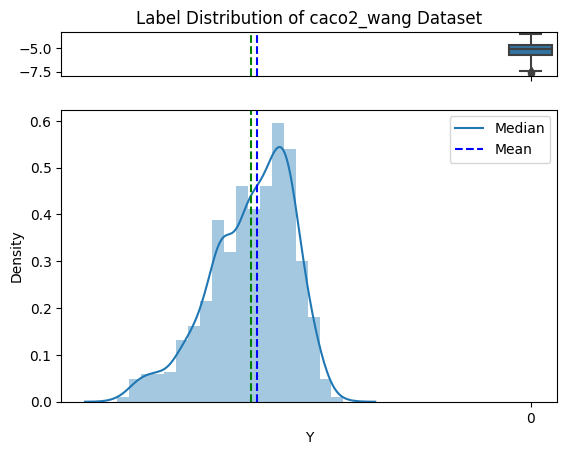

In [ ]:
# data의 distribution의 즉각적 시각화도 가능하다.
data.label_distribution() #y값에 따른 데이터 분포를 보여줌, 가까운걸 보니 이상치가 많은것 같지는 않음

Binariztion using threshold -4.7, default, we assume the smaller values are 1 and larger ones is 0, you can change the order by 'binarize(order = 'ascending')'


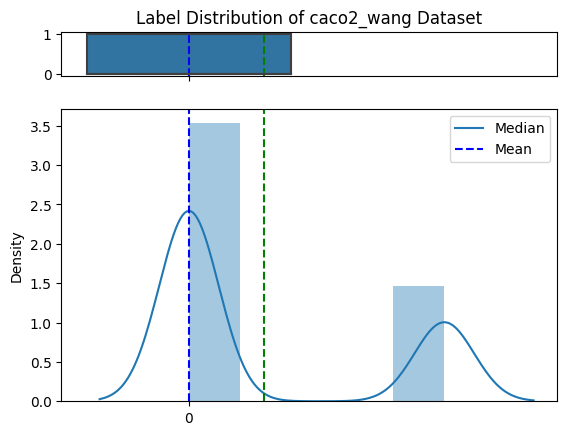

In [ ]:
# 연속형 변수를 이산형으로 쉽게 전환할 수 있다.
data.binarize(threshold = -4.7, order = 'ascending') #-4.7을 기준으로 1과 0으로 바꾸기
data.label_distribution()

## 2. 심장독성 예측 모델 만들기

In [ ]:
from tdc.single_pred import Tox
data = Tox(name = 'hERG')
data.get_data().head(2)#스마일즈 형태로 있고, 1과 0으로 있음/ 1은 심장독성이 있고, 0은 심장 독성이 없음

Downloading...
100%|██████████| 50.2k/50.2k [00:00<00:00, 843kiB/s]
Loading...
Done!


,Drug_ID,Drug,Y
0,DEMETHYLASTEMIZOLE,Oc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1,1.0
1,GBR-12909,Fc1ccc(C(OCC[NH+]2CC[NH+](CCCc3ccccc3)CC2)c2cc...,1.0


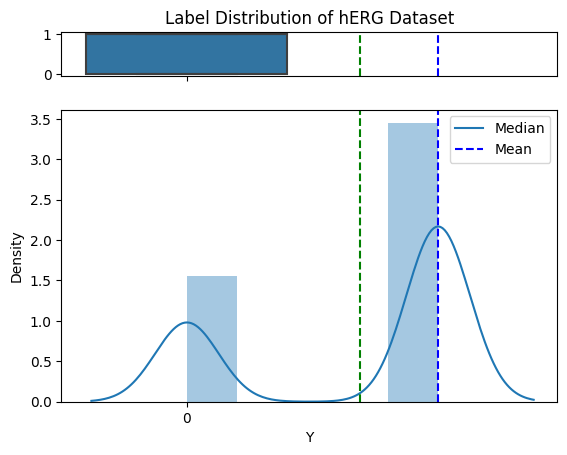

In [ ]:
data.label_distribution()

In [ ]:
# 빠른 학습을 위해 일부 데이터만 이용
split = data.get_split(method = 'scaffold',
                       seed = 42,
                       frac = [0.3, 0, 0.1]) #3대 1로 나누기

100%|██████████| 655/655 [00:00<00:00, 2457.25it/s]


### 2-1. RDKit 다뤄보기

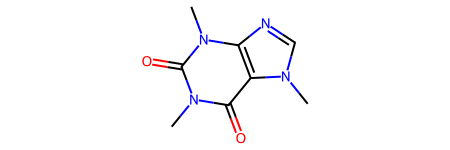

In [ ]:
import rdkit.Chem as Chem
smiles = 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'
m = Chem.MolFromSmiles(smiles)
m
#위에 있는 화합물 중 하나를 가져와서 구조를 보기

In [ ]:
from rdkit.Chem import Descriptors #분자들의 특징을 뽑아 임베딩 하는것도 가능하다~
print(len(Descriptors._descList))
for k in Descriptors._descList[:10]:
    print(k)

208
('MaxEStateIndex', <function MaxEStateIndex at 0x7dfb94a9cb80>)
('MinEStateIndex', <function MinEStateIndex at 0x7dfb94a9cc10>)
('MaxAbsEStateIndex', <function MaxAbsEStateIndex at 0x7dfb94a9cca0>)
('MinAbsEStateIndex', <function MinAbsEStateIndex at 0x7dfb94a9cd30>)
('qed', <function qed at 0x7dfb94a9fd00>)
('MolWt', <function <lambda> at 0x7dfb94acc040>)
('HeavyAtomMolWt', <function HeavyAtomMolWt at 0x7dfb94acc0d0>)
('ExactMolWt', <function <lambda> at 0x7dfb94acc160>)
('NumValenceElectrons', <function NumValenceElectrons at 0x7dfb94acc1f0>)
('NumRadicalElectrons', <function NumRadicalElectrons at 0x7dfb94acc280>)


In [ ]:
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np
def get_all_descriptors(m):
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    ds = calc.CalcDescriptors(m)
    ds = np.array(ds)
    ds[np.isnan(ds)] = 0
    return np.array(ds)

In [ ]:
des = get_all_descriptors(m)
print(des.shape)
print(des[:10])
#화합물을 208차원의 벡터로 만들기

(208,)
[ 11.67203704  -0.36        11.67203704   0.31657407   0.53846283
 194.194      184.114      194.08037556  74.           0.        ]


In [ ]:
def data_processing_desc(df):
    X = np.vstack(df.Drug.apply(lambda m: get_all_descriptors(Chem.MolFromSmiles(m))))
    y = df['Y'].to_numpy()
    return X, y

X_train, y_train = data_processing_desc(split['train'])
X_test, y_test = data_processing_desc(split['test'])

In [ ]:
(X_train.shape, y_train.shape), (X_test.shape, y_test.shape)

(((196, 208), (196,)), ((459, 208), (459,)))

### 2-2. random forest를 이용한 머신러닝 모델 만들기

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_test)[:, 1] #확률값을 추출

In [ ]:
# 평가 지표 설정
from sklearn import metrics
def eval_model(y_test, y_pred):
    print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred > 0.5)}")
    print(f"Log loss: {metrics.log_loss(y_test, y_pred, labels=[0, 1])}")
    precision, recall, _ = metrics.precision_recall_curve(y_test, y_pred, pos_label=1)
    print(f"AUPRC: {metrics.auc(recall, precision)}")
    fpr_roc, tpr_roc, _ = metrics.roc_curve(y_test, y_pred, pos_label=1)
    print(f"AUROC: {metrics.auc(fpr_roc, tpr_roc)}")

In [ ]:
eval_model(y_test, y_pred)

Accuracy: 0.7952069716775599
Log loss: 0.47949868388700123
AUPRC: 0.8785923560154635
AUROC: 0.8088816812547208


### 2-3. ECFP를 이용한 머신러닝 모델 만들기

In [ ]:
import rdkit.Chem.AllChem as AllChem
def data_processing_ECFP(df):
    X = np.vstack(df.Drug.apply(lambda m: list(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(m), 4, nBits=2048))))
    y = df['Y'].to_numpy()
    return X, y

X_train, y_train = data_processing_ECFP(split['train'])
X_test, y_test = data_processing_ECFP(split['test'])

clf = RandomForestClassifier() #ECFP를 이용해 임베딩하고 랜덤 포레스트
clf.fit(X_train, y_train)
y_pred = clf.predict_proba(X_test)[:, 1]

eval_model(y_test, y_pred)

Accuracy: 0.7450980392156863
Log loss: 0.630782828796836
AUPRC: 0.829000195715321
AUROC: 0.7401919402852446


### 2-4.ChemBERTa를 이용한 BERT-based 모델 만들기(1): BERT + Random forest

In [ ]:
from transformers import AutoConfig, AutoTokenizer, AutoModel, Trainer, TrainingArguments, TrainerCallback

model_name = "DeepChem/ChemBERTa-77M-MTR" #모델 가져오기
tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import torch
def data_processing_BERT(df):
    smiles = df['Drug']
    ids = np.array(tokenizer(list(smiles), padding='max_length', max_length=512, truncation=True)['input_ids'])
    bert_output = model(torch.tensor(ids))[0]
    clf_output = bert_output[:, 0, :] #clf로 버트 임베딩
    X = clf_output.detach().numpy()
    y = df['Y'].to_numpy()
    return X, y

X_train, y_train = data_processing_BERT(split['train'])
X_test, y_test = data_processing_BERT(split['test'])

In [ ]:
(X_train.shape, y_train.shape), (X_test.shape, y_test.shape)

(((196, 384), (196,)), ((459, 384), (459,)))

In [ ]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict_proba(X_test)[:, 1]

eval_model(y_test, y_pred)

Accuracy: 0.7821350762527233
Log loss: 0.5084511750091536
AUPRC: 0.8679302946034211
AUROC: 0.7951526191851425


### 2-5.ChemBERTa를 이용한 BERT-based 모델 만들기(2): BERT + DNN

In [ ]:
# Define dastaset and dataloader
from torch.utils.data import Dataset, DataLoader
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, TrainerCallback
class BERTDataset(Dataset): #버트 인코더에 풀리 커넥티드 레이어 붙여서 DNN으로 만들기
    def __init__(self, df):
        self.data = df
        self.data['ids'] = self.smiles_to_ids(df['Drug'])
        self.data['y'] = df['Y'].astype('float32')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        return {'input_ids':row['ids'], 'labels':row['y']}

    def smiles_to_ids(self, smiles):
        ids = tokenizer(list(smiles), padding='max_length', max_length=512, truncation=True)['input_ids'] #데이터를 불러올때마다 토크나이제이션
        return ids

# datasets
train_dataset = BERTDataset(split['train'])
test_dataset = BERTDataset(split['test'])

In [ ]:
# 모델 정의
model_name = "DeepChem/ChemBERTa-77M-MTR"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1) #감성분류 모델을 사용

# if GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU.")
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")

# move model to the device
model.to(device)
#로베타 레이어가 있고 이진 헤드가 있어 로베타 모델 위에 풀리 커넥티드 레이어 하나가 얹어져 있는 그런모델

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['classifier.out_proj.bias', 'classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using GPU.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(600, 384, padding_idx=1)
      (position_embeddings): Embedding(515, 384, padding_idx=1)
      (token_type_embeddings): Embedding(1, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.144, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-2): 3 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.109, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
             

In [ ]:
from transformers import TrainingArguments, Trainer

# TrainerArguments 클래스에 argument 정의
batch_size = 64
epochs = 15
training_args = TrainingArguments(
    output_dir = './outputs',
    logging_dir = './logs',
    num_train_epochs = epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    logging_steps = epochs,
    save_steps= epochs,
    save_total_limit=1
)

# metrics 계산
from datasets import load_metric
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions
    preds = (preds > 0.5) * 1.0
    ma = load_metric('accuracy')
    mf = load_metric('f1')
    acc = ma.compute(predictions=preds, references=labels)['accuracy']
    f1 = mf.compute(predictions=preds, references=labels)['f1']
    return {'accuracy':acc, 'f1':f1}

In [ ]:
# Trainer 클래스 정의 및 학습
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
trainer.train()

Step,Training Loss
15,0.294300
30,0.227800
45,0.185900
60,0.201800


TrainOutput(global_step=60, training_loss=0.22746144930521647, metrics={'train_runtime': 23.7658, 'train_samples_per_second': 123.707, 'train_steps_per_second': 2.525, 'total_flos': 27088546222080.0, 'train_loss': 0.22746144930521647, 'epoch': 15.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.20962511003017426,
 'eval_accuracy': 0.6862745098039216,
 'eval_f1': 0.8124999999999999,
 'eval_runtime': 2.2936,
 'eval_samples_per_second': 200.124,
 'eval_steps_per_second': 3.488,
 'epoch': 15.0}

## 3. DeepChem을 이용한 GNN 모델 실습

In [ ]:
import deepchem as dc

tasks, datasets, transformers = dc.molnet.load_tox21(featurizer='GraphConv')
train_dataset, valid_dataset, test_dataset = datasets

In [ ]:
n_tasks = len(tasks)
model = dc.models.GraphConvModel(n_tasks, mode='classification') #모델 구조 직접 가지고오기
model.fit(train_dataset, nb_epoch=50)

0.27676982879638673

In [ ]:
metric = dc.metrics.Metric(dc.metrics.roc_auc_score)
print('Training set score:', model.evaluate(train_dataset, [metric], transformers))
print('Test set score:', model.evaluate(test_dataset, [metric], transformers))

Training set score: {'roc_auc_score': 0.9715972974614289}
Test set score: {'roc_auc_score': 0.7034972112403007}


## 4. ZINC Clean Leads dataset 소개

In [ ]:
# ZINC clean leads dataset download
import pandas as pd
!wget https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv
df_zinc = pd.read_csv('250k_rndm_zinc_drugs_clean_3.csv')
print(df_zinc.shape)
df_zinc.head()

--2023-10-29 12:59:19--  https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22606589 (22M) [text/plain]
Saving to: ‘250k_rndm_zinc_drugs_clean_3.csv.3’

250k_rndm_zinc_drug 100%[===================>]  21.56M  --.-KB/s    in 0.1s    

2023-10-29 12:59:19 (216 MB/s) - ‘250k_rndm_zinc_drugs_clean_3.csv.3’ saved [22606589/22606589]

(249455, 4)


,smiles,logP,qed,SAS
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182


In [ ]:
df_zinc['smiles'] = df_zinc['smiles'].apply(lambda x: x.strip())

## 5. RandomForest 모델을 이용하여 심장독성 가상 스크리닝

In [ ]:
zinc_small = df_zinc.head(1000)
zinc_small

,smiles,logP,qed,SAS
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182
...,...,...,...,...
995,ClCCc1nc2cccnc2n1CCn1cccn1,2.10930,0.672897,2.506188
996,CC[C@@](C)([C@@H]([NH3+])c1cc(Br)ccc1F)N1CCOCC1,2.37210,0.910031,3.884291
997,Cc1ccc(NC(=O)c2cc3ccccc3oc2=O)c([N+](=O)[O-])c1,3.26192,0.444910,1.998848
998,CC1(C)OC[C@H]([C@H]2O[C@@H]3OC(C)(C)O[C@@H]3[C...,0.35910,0.696755,4.270988


In [ ]:
from tqdm import tqdm
def get_herg(smiles_list):
    X = np.array([(get_all_descriptors(Chem.MolFromSmiles(m))) for m in smiles_list])
    pred = rf.predict(X)
    return list(pred)

def herg_virtual_screening(smiles_list):
    output = []
    for i in tqdm(range(0, len(smiles_list), 10)):
        sublist = smiles_list[i:i+10]
        pred = get_herg(sublist)
        output += pred
    return output

In [ ]:
zinc_small['hERG'] = herg_virtual_screening(zinc_small['smiles'])

100%|██████████| 100/100 [00:09<00:00, 10.61it/s]


In [ ]:
zinc_small

,smiles,logP,qed,SAS,hERG
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1,5.05060,0.702012,2.084095,1.0
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1,3.11370,0.928975,3.432004,1.0
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633,1.0
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753,1.0
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182,1.0
...,...,...,...,...,...
995,ClCCc1nc2cccnc2n1CCn1cccn1,2.10930,0.672897,2.506188,0.0
996,CC[C@@](C)([C@@H]([NH3+])c1cc(Br)ccc1F)N1CCOCC1,2.37210,0.910031,3.884291,1.0
997,Cc1ccc(NC(=O)c2cc3ccccc3oc2=O)c([N+](=O)[O-])c1,3.26192,0.444910,1.998848,1.0
998,CC1(C)OC[C@H]([C@H]2O[C@@H]3OC(C)(C)O[C@@H]3[C...,0.35910,0.696755,4.270988,0.0


In [ ]:
zinc_small[zinc_small['hERG']==1]

,smiles,logP,qed,SAS,hERG
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1,5.05060,0.702012,2.084095,1.0
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1,3.11370,0.928975,3.432004,1.0
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633,1.0
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753,1.0
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182,1.0
...,...,...,...,...,...
993,Cc1ccc(N2C(=O)[C@@H](Cc3cccc(C)c3)S/C2=C(/C#N)...,3.21502,0.644574,2.911876,1.0
994,CC(C)CN(C(=O)NCc1ccc(C(F)(F)F)cc1)C1CC1,4.03540,0.842417,2.138039,1.0
996,CC[C@@](C)([C@@H]([NH3+])c1cc(Br)ccc1F)N1CCOCC1,2.37210,0.910031,3.884291,1.0
997,Cc1ccc(NC(=O)c2cc3ccccc3oc2=O)c([N+](=O)[O-])c1,3.26192,0.444910,1.998848,1.0


# Hit Discovery

1. DeepPurpose 설치
2. ZINC Clean Leads dataset 소개
3. 코로나 바이러스 치료제 후보물질 도출(Ligand-based)
4. DeepPurpose를 이용한 deepDTA 구현
5. DeepPurpose 사전학습 모델을 이용한 DTI 실습
6. 가상 스크리닝 실습(독성, 효력)



## 1. DeepPurpose 설치
단백질과 화합물의 인코더를 넣기만 하면 알아서 딥러닝 모델을 만들어줌

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install_anaconda()

⏬ Downloading https://repo.anaconda.com/archive/Anaconda3-2023.03-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:58
🔁 Restarting kernel...


In [ ]:
import condacolab
condacolab.check()
!conda --version

✨🍰✨ Everything looks OK!
/bin/bash: /usr/local/lib/libtinfo.so.6: no version information available (required by /bin/bash)
conda 23.3.1


In [ ]:
%%bash
conda create -n DeepPurpose python=3.6
source activate DeepPurpose
conda install -c conda-forge notebook
pip install git+https://github.com/bp-kelley/descriptastorus
pip install DeepPurpose

Process is terminated.


In [ ]:
!conda install -yq -c conda-forge -c  rdkit notebook

/bin/bash: /usr/local/lib/libtinfo.so.6: no version information available (required by /bin/bash)

CondaError: KeyboardInterrupt



In [ ]:
# Dependencies 설치
!pip -q install PyTDC
!pip -q install rdkit-pypi
!pip install -U accelerate
!pip install -U transformers
!pip install datasets
!pip install --pre deepchem

/bin/bash: /usr/local/lib/libtinfo.so.6: no version information available (required by /bin/bash)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 63.7 MB/s eta 0:00:00
/bin/bash: /usr/local/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/bin/bash: /usr/local/lib/libtinfo.so.6: no version information available (required by /bin/bash)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 5.6 MB/s eta 0:00:00
/bin/bash: /usr/local/lib/libtinfo.so.6: no version information available (required by /bin/bash)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 54.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 86.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 35.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 102.8 MB/s eta 0:00:00
 

## 1. ZINC clean dataset

In [ ]:
# ZINC clean leads dataset download
import pandas as pd
!wget https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv
df_zinc = pd.read_csv('250k_rndm_zinc_drugs_clean_3.csv')
print(df_zinc.shape)
df_zinc.head()

/bin/bash: /usr/local/lib/libtinfo.so.6: no version information available (required by /bin/bash)
--2023-10-30 11:29:43--  https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22606589 (22M) [text/plain]
Saving to: ‘250k_rndm_zinc_drugs_clean_3.csv’

250k_rndm_zinc_drug 100%[===================>]  21.56M  --.-KB/s    in 0.1s    

2023-10-30 11:29:44 (150 MB/s) - ‘250k_rndm_zinc_drugs_clean_3.csv’ saved [22606589/22606589]

(249455, 4)


,smiles,logP,qed,SAS
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182


In [ ]:
zinc_small = df_zinc.head(1000)
zinc_small

,smiles,logP,qed,SAS
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182
...,...,...,...,...
995,ClCCc1nc2cccnc2n1CCn1cccn1\n,2.10930,0.672897,2.506188
996,CC[C@@](C)([C@@H]([NH3+])c1cc(Br)ccc1F)N1CCOCC1\n,2.37210,0.910031,3.884291
997,Cc1ccc(NC(=O)c2cc3ccccc3oc2=O)c([N+](=O)[O-])c1\n,3.26192,0.444910,1.998848
998,CC1(C)OC[C@H]([C@H]2O[C@@H]3OC(C)(C)O[C@@H]3[C...,0.35910,0.696755,4.270988


## 2. 코로나 바이러스 치료제 후보물질 도출(Ligand-based)

In [ ]:
from tdc.single_pred import HTS
data = HTS(name = 'SARSCoV2_3CLPro_Diamond') #코로나 바이러스의 이거랑 결합하면 잠재적인 바이러스 치료제 가능
split = data.get_split()

Downloading...
100%|██████████| 28.9k/28.9k [00:00<00:00, 759kiB/s]
Loading...
Done!


In [ ]:
data.get_data() #1인 애들은 결합하고 0인 애들은 결합하지 않음

,Drug_ID,Drug,Y
0,0,Oc1ccccc1CNc1nc2ccccc2[nH]1,1
1,1,CC(=O)NCCc1c[nH]c2ccc(F)cc12,1
2,2,NC(=O)[C@H]1CCC[C@H]1c1ccsc1,1
3,3,CN1CCCc2ccc(S(N)(=O)=O)cc21,1
4,4,CC(=O)Nc1ccc(Oc2ncccn2)cc1,1
...,...,...,...
875,875,CC(C)c1ccc(NC(=O)N2CCOCC2)cc1,0
876,876,CN(CC(=O)O)C(=O)c1ccccn1,0
877,877,CN1CCN(C(=O)c2ccc(F)c(F)c2)CC1,0
878,878,O=C(c1c(F)cccc1F)N1CCCCCC1,0


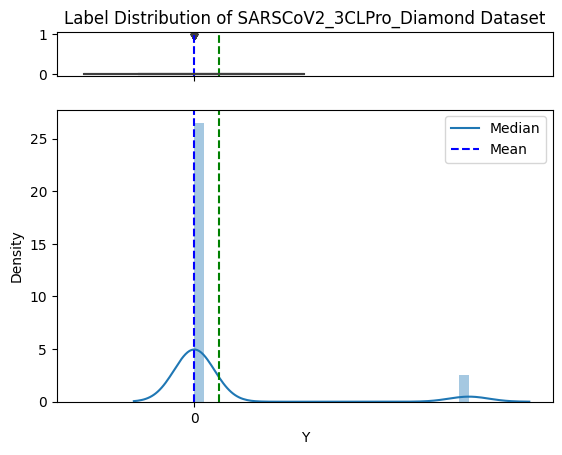

In [ ]:
data.label_distribution()

In [ ]:
import rdkit.Chem as Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np
import pandas as pd

def get_all_descriptors(m):
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    ds = calc.CalcDescriptors(m)
    ds = np.array(ds)
    ds[np.isnan(ds)] = 0
    return np.array(ds)

def data_processing_desc(df):
    X = np.vstack(df.Drug.apply(lambda m: get_all_descriptors(Chem.MolFromSmiles(m))))
    y = df['Y'].to_numpy()
    return X, y

X_train, y_train = data_processing_desc(split['train'])
X_test, y_test = data_processing_desc(split['test'])

# 평가 지표 설정
from sklearn import metrics
def eval_model(y_test, y_pred):
    print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred > 0.5)}")
    print(f"Log loss: {metrics.log_loss(y_test, y_pred, labels=[0, 1])}")
    precision, recall, _ = metrics.precision_recall_curve(y_test, y_pred, pos_label=1)
    print(f"AUPRC: {metrics.auc(recall, precision)}")
    fpr_roc, tpr_roc, _ = metrics.roc_curve(y_test, y_pred, pos_label=1)
    print(f"AUROC: {metrics.auc(fpr_roc, tpr_roc)}")

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_test)[:, 1]

eval_model(y_test, y_pred)

Accuracy: 0.8693181818181818
Log loss: 0.3104002694345888
AUPRC: 0.3548969188097285
AUROC: 0.7621794871794872


In [ ]:
from tqdm import tqdm
def get_3CLpro(smiles_list):
    X = np.array([(get_all_descriptors(Chem.MolFromSmiles(m))) for m in smiles_list])
    pred = rf.predict(X)
    return list(pred)

def virtual_screening_3CLpro(smiles_list):
    output = []
    for i in tqdm(range(0, len(smiles_list), 10)):
        sublist = smiles_list[i:i+10]
        pred = get_3CLpro(sublist)
        output += pred
    return output

In [ ]:
zinc_small['3CLPro'] = virtual_screening_3CLpro(zinc_small['smiles'])

100%|██████████| 100/100 [00:12<00:00,  8.03it/s]


In [ ]:
zinc_small

,smiles,logP,qed,SAS,3CLPro
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095,0
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004,1
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633,0
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753,0
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182,0
...,...,...,...,...,...
995,ClCCc1nc2cccnc2n1CCn1cccn1\n,2.10930,0.672897,2.506188,0
996,CC[C@@](C)([C@@H]([NH3+])c1cc(Br)ccc1F)N1CCOCC1\n,2.37210,0.910031,3.884291,0
997,Cc1ccc(NC(=O)c2cc3ccccc3oc2=O)c([N+](=O)[O-])c1\n,3.26192,0.444910,1.998848,0
998,CC1(C)OC[C@H]([C@H]2O[C@@H]3OC(C)(C)O[C@@H]3[C...,0.35910,0.696755,4.270988,0


In [ ]:
len(zinc_small[zinc_small['3CLPro']==1])

42

In [ ]:
GNINA, diffdock

## 4. DeepPurpose를 이용한 deepDTA 구현


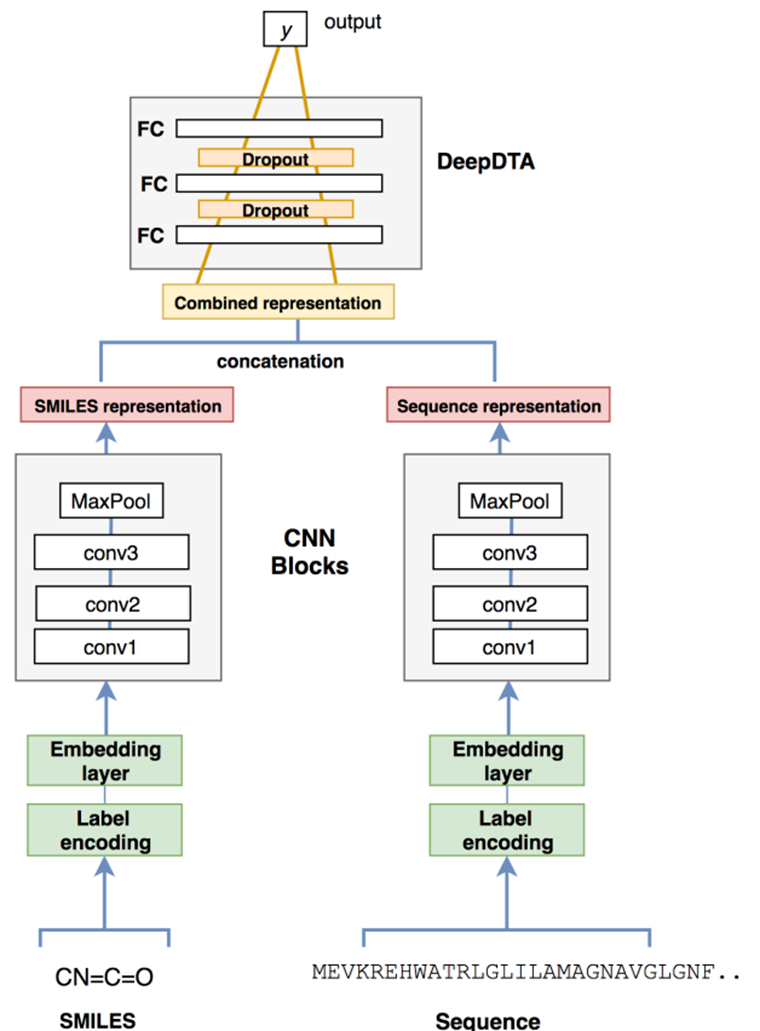

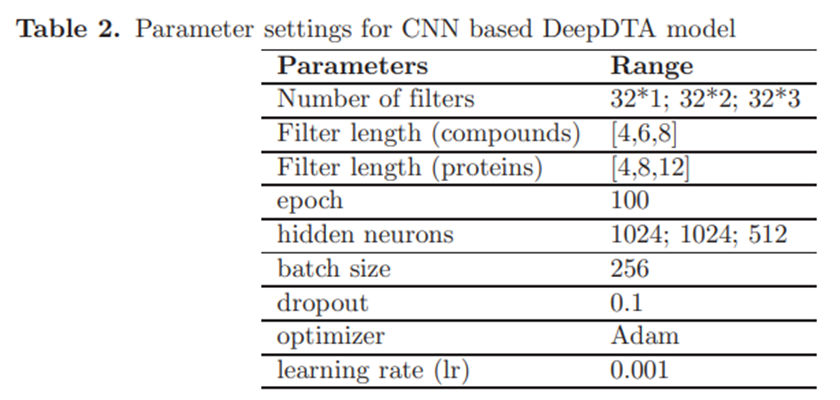

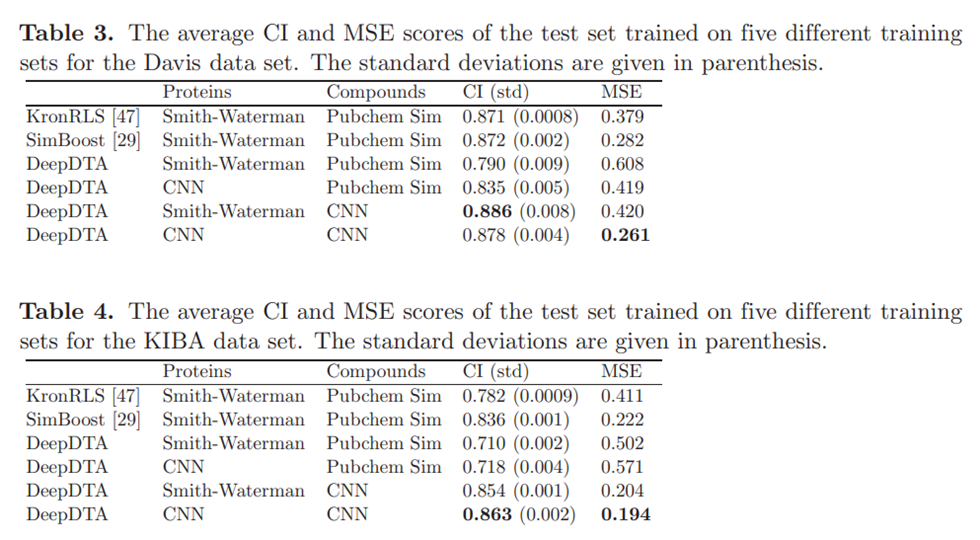

In [ ]:
import DeepPurpose.DTI as models
from DeepPurpose.utils import *
from DeepPurpose.dataset import *

X_drug, X_target, y = load_process_DAVIS('./data/', binary=False)

drug_encoding = 'CNN'
target_encoding = 'CNN'
train, val, test = data_process(X_drug, X_target, y,
                                drug_encoding, target_encoding,
                                split_method='random',frac=[0.7,0.1,0.2])

# use the parameters setting provided in the paper: https://arxiv.org/abs/1801.10193
config = generate_config(drug_encoding = drug_encoding,
                         target_encoding = target_encoding,
                         cls_hidden_dims = [1024,1024,512],
                         train_epoch = 100,
                         LR = 0.001,
                         batch_size = 256,
                         cnn_drug_filters = [32,64,96],
                         cnn_target_filters = [32,64,96],
                         cnn_drug_kernels = [4,6,8],
                         cnn_target_kernels = [4,8,12]
                        )

In [ ]:
model = models.model_initialize(**config)
model.train(train, val, test)

In [ ]:
model.save_model('./model_DeepDTA')

## 5. DeepPurpose 사전학습 모델

In [ ]:
from DeepPurpose import DTI as models #학습되어있는 모델을 제공해서 버츄얼 스크리닝 가능
model = models.model_pretrained(model = 'MPNN_CNN_DAVIS')
model.config

ModuleNotFoundError: ignored

In [ ]:
# 3CLpro
# https://www.rcsb.org/structure/6m2q
protein_sequence = "SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTSEDMLNPNYEDLLIRKSNHNFLVQAGNVQLRVIGHSMQNCVLKLKVDTANPKTPKYKFVRIQPGQTFSVLACYNGSPSGVYQCAMRPNFTIKGSFLNGSCGSVGFNIDYDCVSFCYMHHMELPTGVHAGTDLEGNFYGPFVDRQTAQAAGTDTTITVNVLAWLYAAVINGDRWFLNRFTTTLNDFNLVAMKYNYEPLTQDHVDILGPLSAQTGIAVLDMCASLKELLQNGMNGRTILGSALLEDEFTPFDVVRQCSGVTFQ"
smiles_list = list(zinc_small['smiles'])
labels = [f'ZINC{i}'for i in range(len(smiles_list))]
target = '3CLpro'

# virtual screening
results = models.virtual_screening(smiles_list, [protein_sequence], model, labels, [target])
zinc_small['score'] = results